<a href="https://colab.research.google.com/github/pranavkhera1-creator/assignment_03_bitsom_ba_2511204_python_part-4/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np


In [5]:
df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [6]:
print(df.shape)
print(df.dtypes)

(15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [7]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [8]:
print(df['passed'].value_counts())


passed
1    9
0    6
Name: count, dtype: int64


In [9]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("Passing students average:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nFailing students average:")
print(df[df['passed'] == 0][subject_cols].mean())


Passing students average:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Failing students average:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [10]:
df['temp_avg'] = df[subject_cols].mean(axis=1)
top = df.loc[df['temp_avg'].idxmax(), 'name']
print("Top student:", top)

Top student: Diana


In [11]:
df['avg_score'] = df[subject_cols].mean(axis=1)


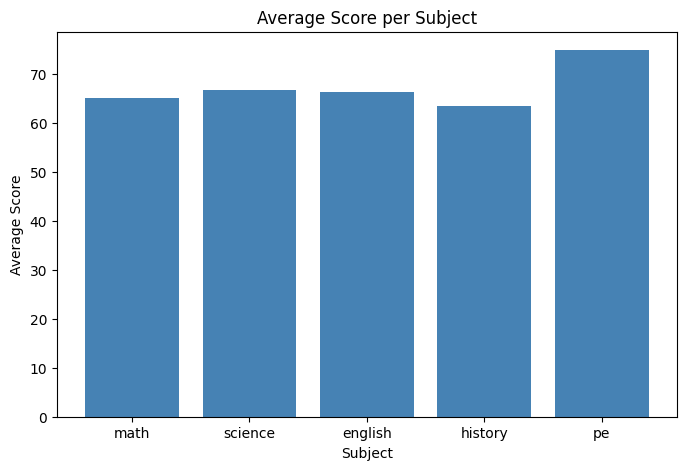

In [12]:
plt.figure(figsize=(8,5))
plt.bar(subject_cols, df[subject_cols].mean(), color='steelblue')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


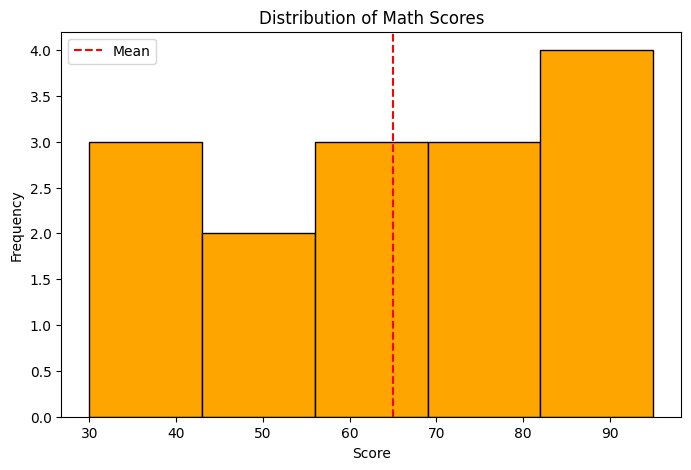

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df['math'], bins=5, color='orange', edgecolor='black')
plt.axvline(df['math'].mean(), linestyle='--', color='red', label='Mean')
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

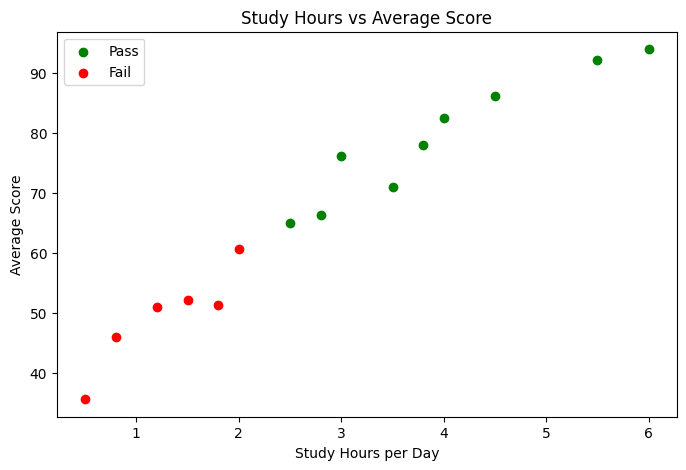

In [14]:
plt.figure(figsize=(8,5))
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_36885/2281248224.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


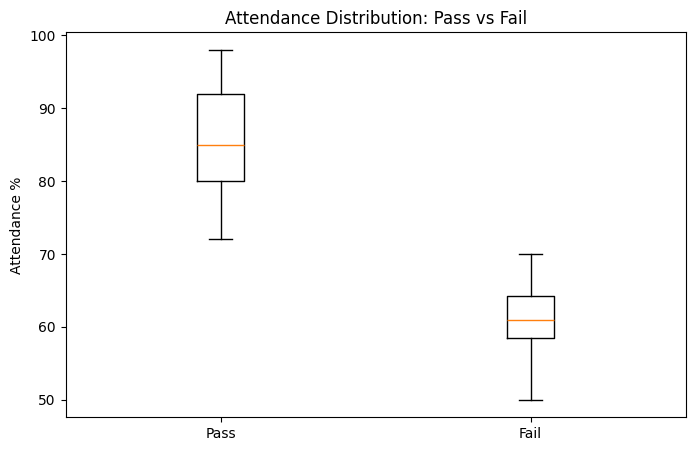

In [15]:
plt.figure(figsize=(8,5))
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_boxplot.png")
plt.show()


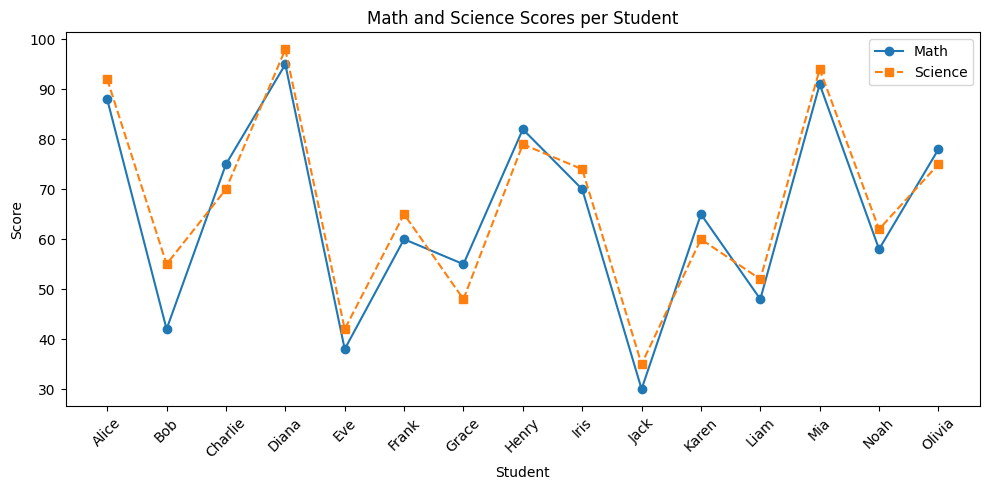

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.xticks(rotation=45)
plt.title("Math and Science Scores per Student")
plt.xlabel("Student")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

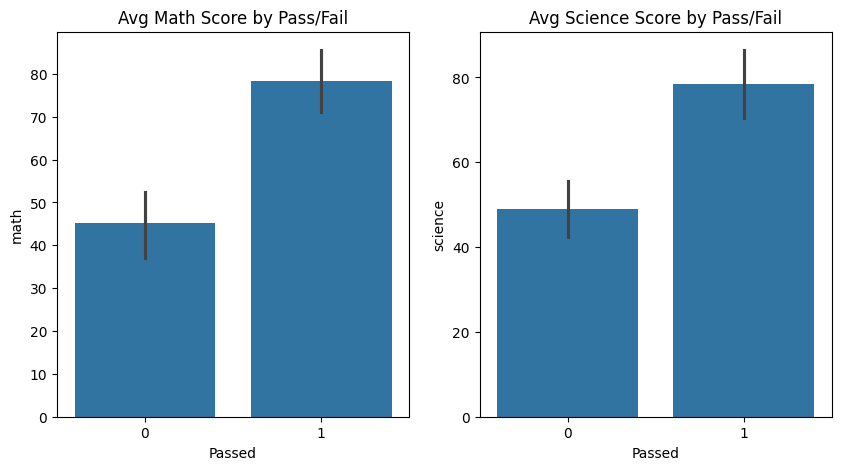

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Avg Math Score by Pass/Fail")
ax1.set_xlabel("Passed")
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Avg Science Score by Pass/Fail")
ax2.set_xlabel("Passed")
plt.savefig("plot6_seaborn_bar.png")
plt.show()



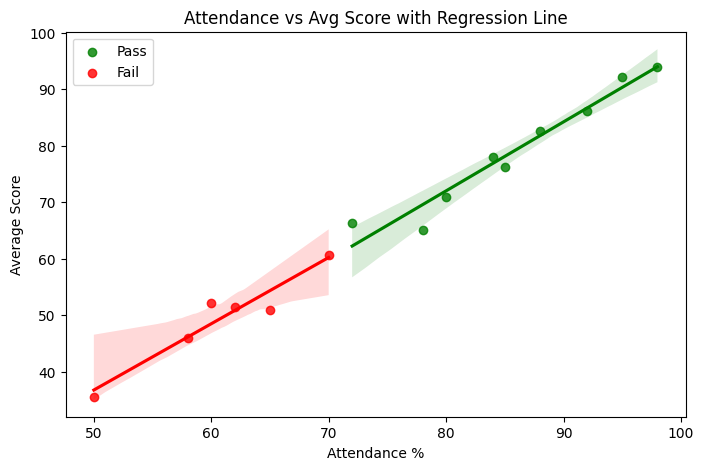

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='green')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red')
plt.title("Attendance vs Avg Score with Regression Line")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Seaborn needed less code to produce styled plots compared to Matplotlib.
# Matplotlib required manually setting colours, labels, and loops for grouped plots.
# For quick grouped visualizations, Seaborn is more convenient; Matplotlib gives more control.


In [19]:
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12
Testing samples: 3


In [20]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
print("Training Accuracy:", model.score(X_train_scaled, y_train))


Training Accuracy: 1.0


In [21]:
y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", model.score(X_test_scaled, y_test))

names = df.loc[X_test.index, 'name']
for name, actual, predicted in zip(names, y_test, y_pred):
    status = "✅" if actual == predicted else "❌"
    print(f"{name}: Actual={actual}, Predicted={predicted} {status}")


Test Accuracy: 1.0
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅


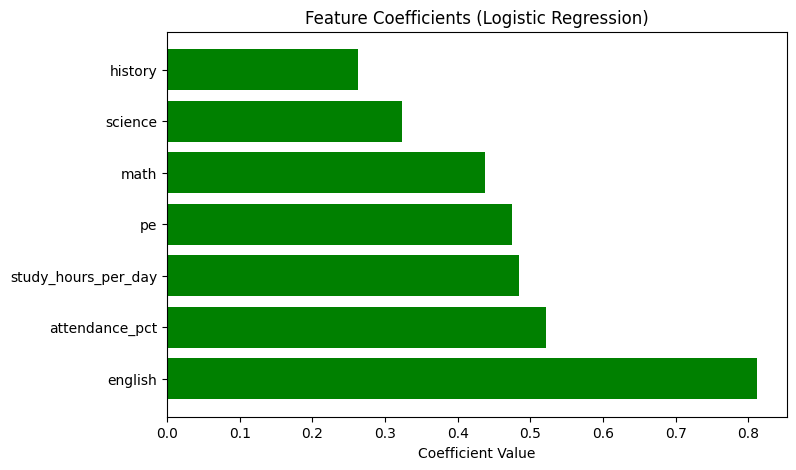

In [22]:
coefficients = model.coef_[0]
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
sorted_features = [feature_cols[i] for i in sorted_idx]
sorted_coefs = [coefficients[i] for i in sorted_idx]

colors = ['green' if c > 0 else 'red' for c in sorted_coefs]
plt.figure(figsize=(8,5))
plt.barh(sorted_features, sorted_coefs, color=colors)
plt.title("Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("plot8_coefficients.png")
plt.show()

In [23]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled = scaler.transform(new_student)
prediction = model.predict(new_scaled)
proba = model.predict_proba(new_scaled)
print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")
print("Probability [Fail, Pass]:", proba)

Prediction: Pass
Probability [Fail, Pass]: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
